In [41]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Euclid imports
from cloelite.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
#from cloelite.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelite.observables.photo import ShearTracer, PositionsTracer
from cloelite.summary_statistics.angular_two_point import AngularTwoPoint
import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

## Cosmology: Background + Perturbations

Shows how to use CAMB and HMCode2020emu

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


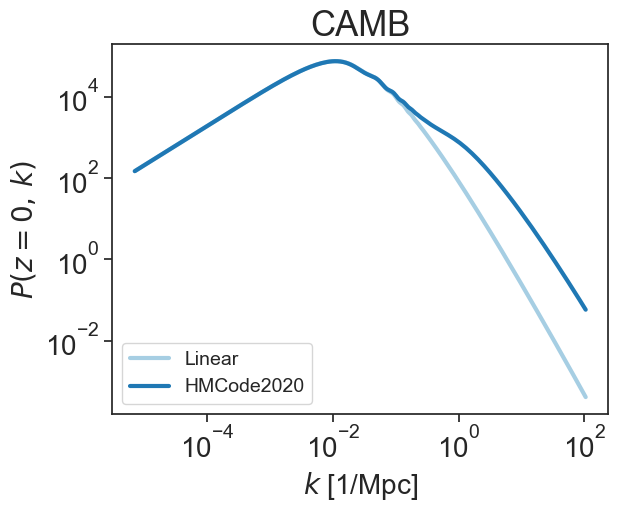

In [42]:
zs = np.linspace(1e-4, 3, 100)

background = CAMBBackground(H0=67.7, 
                            Omega_cdm0=0.26067408193677466, 
                            Omega_b0=0.04902591806322532, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.966, 
                            As = 2e-9,
                            gamma_MG = 0.545)
linear_perturbations = CAMBLinearPerturbations(background, zs)
pk_values_linear = linear_perturbations.matter_power_spectrum()

nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, nonlinear_model = 'mead')
pk_values_nonlinear = nonlinear_perturbations.matter_power_spectrum()

plt.loglog(linear_perturbations.k, pk_values_linear[0, :], label='Linear');
plt.loglog(nonlinear_perturbations.k, pk_values_nonlinear[0, :], label='HMCode2020');
plt.xlabel(r'$k$ [1/Mpc]');
plt.ylabel(r'$P(z=0, \, k)$');
plt.title('CAMB');
plt.legend();

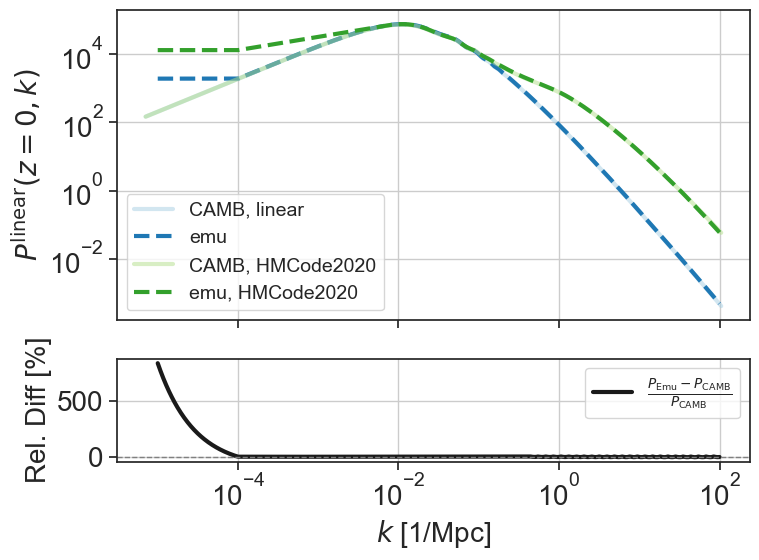

In [43]:
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, zs)
ks_for_emu = np.logspace(-5, 2, 1000)
pk_values_linear_emu = linear_perturbations_emu.matter_power_spectrum(linear_perturbations_emu.z, 
                                                                  ks_for_emu)

pk_values_nonlinear_emu = nonlinear_perturbations_emu.matter_power_spectrum(nonlinear_perturbations_emu.z, 
                                                                  ks_for_emu)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [3, 1]})

# First plot: Power spectra
ax[0].loglog(linear_perturbations.k, pk_values_linear[0, :], label='CAMB, linear', alpha=0.5)
ax[0].loglog(ks_for_emu, pk_values_linear_emu[0, :], '--', label='emu')
ax[0].loglog(nonlinear_perturbations.k, pk_values_nonlinear[0, :], label='CAMB, HMCode2020', alpha=0.5)
ax[0].loglog(ks_for_emu, pk_values_nonlinear_emu[0, :], '--', label='emu, HMCode2020')

ax[0].set_ylabel(r'$P^{\rm linear}(z=0, k)$')
ax[0].legend()
ax[0].grid()

# Compute relative difference
interp_camb = interp1d(linear_perturbations.k, pk_values_linear[0, :], kind='linear', bounds_error=False, fill_value="extrapolate")
pk_camb_interp = interp_camb(ks_for_emu)

relative_diff = 100*(pk_values_linear_emu[0, :] - pk_camb_interp) / pk_camb_interp

# Second plot: Relative difference
ax[1].semilogx(ks_for_emu, relative_diff, 'k-', label=r'$\frac{P_{\mathrm{Emu}} - P_{\mathrm{CAMB}}}{P_{\mathrm{CAMB}}}$')
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)
ax[1].set_xlabel(r'$k$ [1/Mpc]')
ax[1].set_ylabel('Rel. Diff [%]')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()


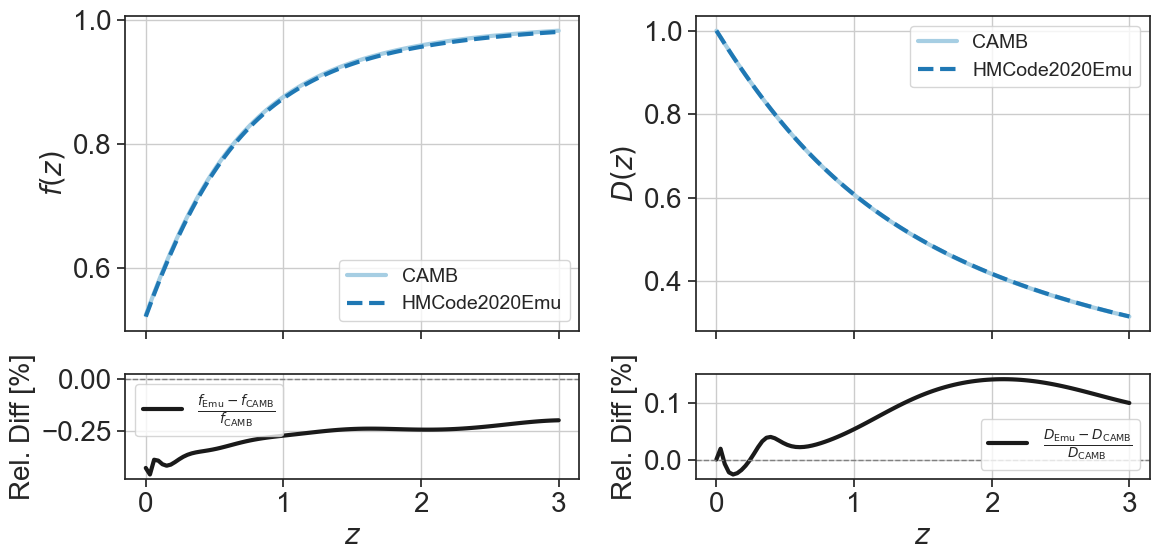

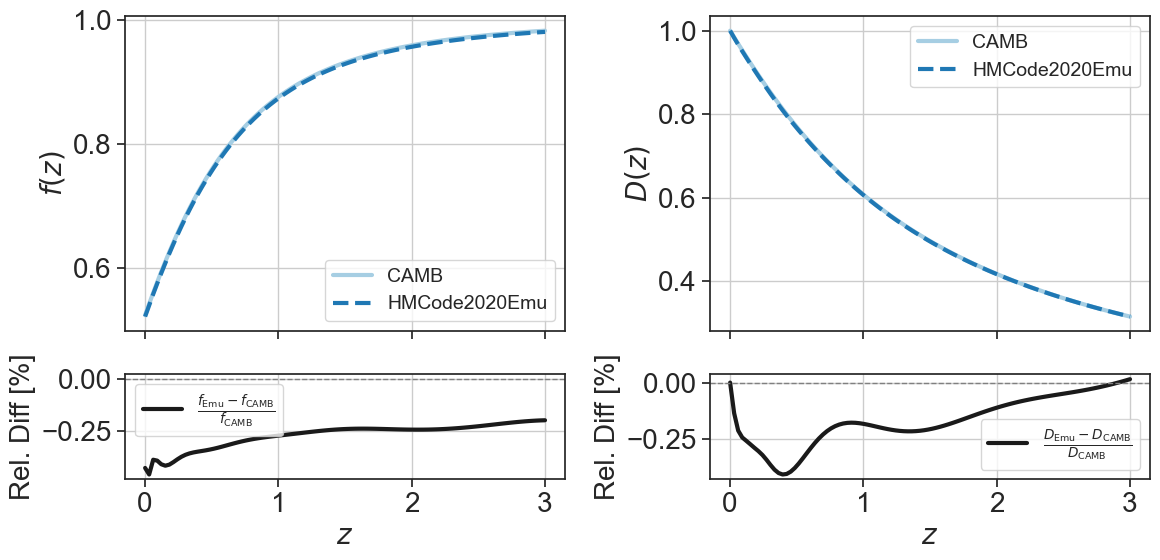

In [44]:
def plot_growth_comparison(camb_perturbations, emu_perturbations):
    """
    Plots the growth rate and growth factor comparisons between CAMB and HMCode2020Emu.
    
    Parameters:
    - camb_perturbations: Object containing growth rate and growth factor from CAMB.
    - emu_perturbations: Object containing growth rate and growth factor from HMCode2020Emu.
    """
    
    fig, ax = plt.subplots(2, 2, sharex=True, figsize=(12, 6), gridspec_kw={'height_ratios': [3, 1]})

    # Growth rate comparison (Left panel)
    ax[0, 0].plot(camb_perturbations.z[::-1], camb_perturbations.growth_rate(), label='CAMB')
    ax[0, 0].plot(emu_perturbations.params_hm_emu['z'], 
                  emu_perturbations.growth_rate(), 
                  '--', 
                  label='HMCode2020Emu')

    ax[0, 0].set_ylabel(r'$f(z)$')
    ax[0, 0].legend()
    ax[0, 0].grid()

    # Compute relative difference for growth rate
    z_emu = emu_perturbations.params_hm_emu['z']
    growth_camb = camb_perturbations.growth_rate()
    growth_emu = emu_perturbations.growth_rate()

    interp_camb = interp1d(camb_perturbations.z[::-1], growth_camb, kind='linear', bounds_error=False, fill_value="extrapolate")
    growth_camb_interp = interp_camb(z_emu)

    relative_diff_rate = 100 * (growth_emu - growth_camb_interp) / growth_camb_interp

    ax[1, 0].plot(z_emu, relative_diff_rate, 'k-', label=r'$\frac{f_{\mathrm{Emu}} - f_{\mathrm{CAMB}}}{f_{\mathrm{CAMB}}}$')
    ax[1, 0].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[1, 0].set_xlabel(r'$z$')
    ax[1, 0].set_ylabel('Rel. Diff [%]')
    ax[1, 0].legend()
    ax[1, 0].grid()

    # Growth factor comparison (Right panel)
    ax[0, 1].plot(camb_perturbations.z, camb_perturbations.growth_factor()[:, 0], label='CAMB')
    ax[0, 1].plot(z_emu, 
                  emu_perturbations.growth_factor(z_emu, 0)[:, 0], 
                  '--', 
                  label='HMCode2020Emu')

    ax[0, 1].set_ylabel(r'$D(z)$')
    ax[0, 1].legend()
    ax[0, 1].grid()

    # Compute relative difference for growth factor
    growth_camb = camb_perturbations.growth_factor()[:, 0]
    growth_emu = emu_perturbations.growth_factor(z_emu, 0)[:, 0]

    interp_camb = interp1d(camb_perturbations.z, growth_camb, kind='linear', bounds_error=False, fill_value="extrapolate")
    growth_camb_interp = interp_camb(z_emu)

    relative_diff_factor = 100 * (growth_emu - growth_camb_interp) / growth_camb_interp

    ax[1, 1].plot(z_emu, relative_diff_factor, 'k-', label=r'$\frac{D_{\mathrm{Emu}} - D_{\mathrm{CAMB}}}{D_{\mathrm{CAMB}}}$')
    ax[1, 1].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[1, 1].set_xlabel(r'$z$')
    ax[1, 1].set_ylabel('Rel. Diff [%]')
    ax[1, 1].legend()
    ax[1, 1].grid()

    plt.tight_layout()
    plt.show()

plot_growth_comparison(linear_perturbations, linear_perturbations_emu)
plot_growth_comparison(nonlinear_perturbations, nonlinear_perturbations_emu)


## Reading n(z)

Currently using Heracles default example for its tutorials

In [58]:
z, nz_heracles = el.photo.redshift_distributions('../data/nz_example_heracles.fits')

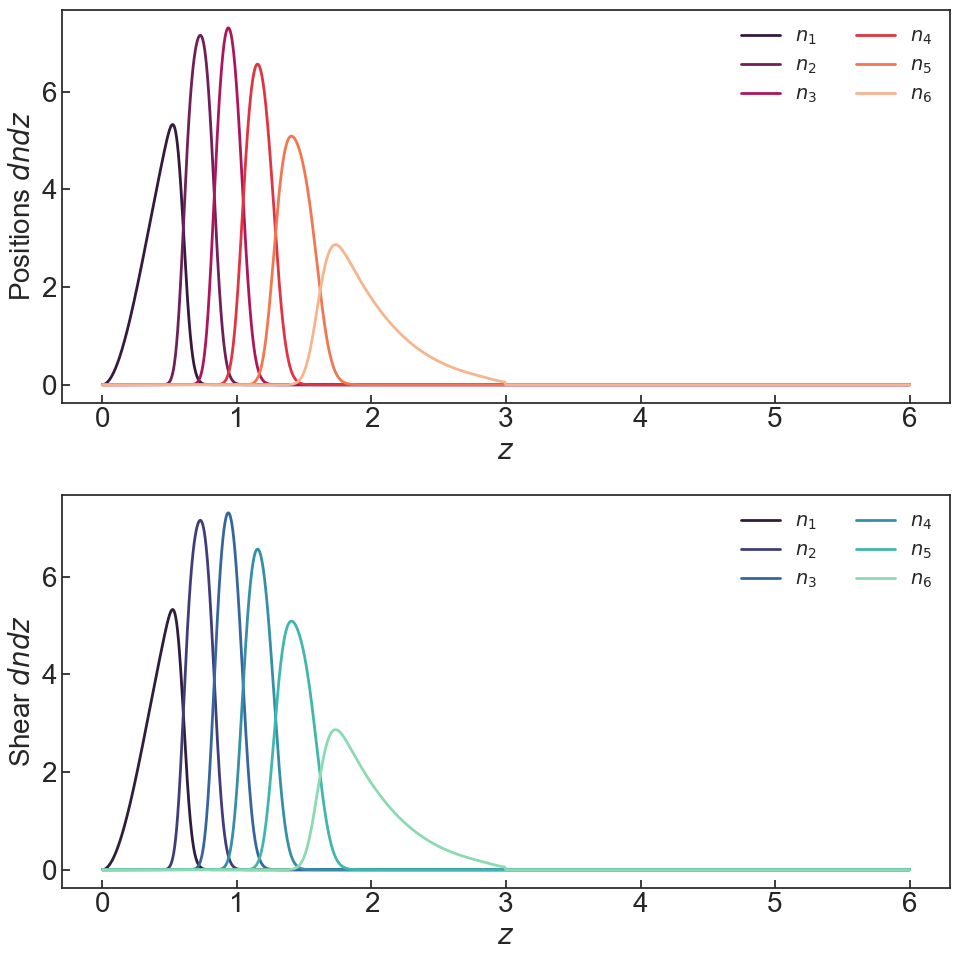

In [59]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in nz_heracles.keys():
    axs[0].plot(z, nz_heracles[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in nz_heracles.keys():
    axs[1].plot(z, nz_heracles[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $dndz$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $dndz$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [60]:
# Normalise dndz
dndz_pos_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_pos_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z)

dndz_she_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_she_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z)


# Resampling the normalized n(z) with 300 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_pos_norm = np.zeros([len(nz_heracles.keys()), 100])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z, my_dndz_pos[i,:])

my_dndz_she = np.vstack(list(dndz_she_norm.values()))
myz = np.linspace(1e-4, 3., 100)
my_dndz_she_norm = np.zeros([len(nz_heracles.keys()), 100])
for i in range(6):
    my_dndz_she_norm[i,:] = np.interp(myz, z, my_dndz_she[i,:])

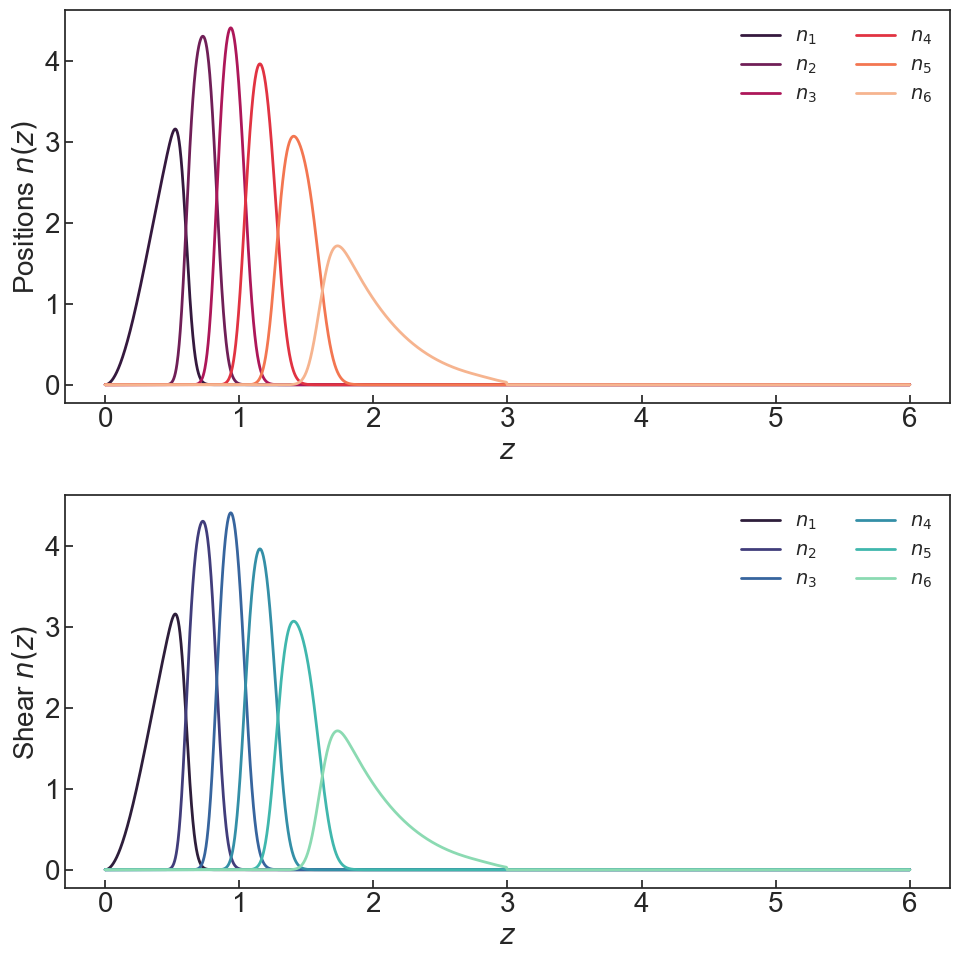

In [61]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in nz_heracles.keys():
    axs[0].plot(z, dndz_pos_norm[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in nz_heracles.keys():
    axs[1].plot(z, dndz_she_norm[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

## Observables: shear and position tracers 

In [72]:
# Define the tracers

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = nonlinear_perturbations.z)

tracer_she = ShearTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_she_norm,
                             z = nonlinear_perturbations.z,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41})

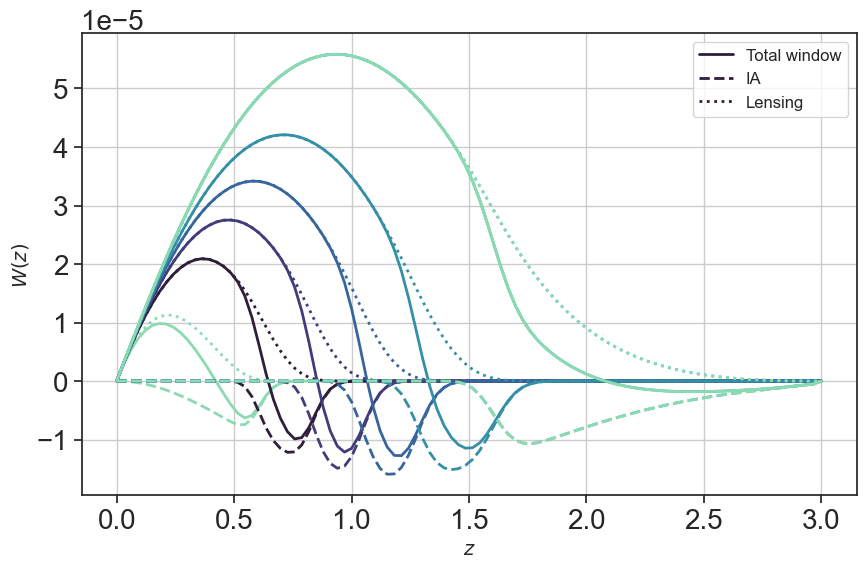

In [75]:
colors = sns.color_palette("mako", len(nz_heracles.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop
for i in range(0, 7):
    # Plot the window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_window_IA(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'IA' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(nonlinear_perturbations.z, 
             tracer_she.get_lensing_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Lensing' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$W(z)$', fontsize=14)

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


In [80]:
tracer_pos.get_window(nonlinear_perturbations.z).shape

(6, 100)

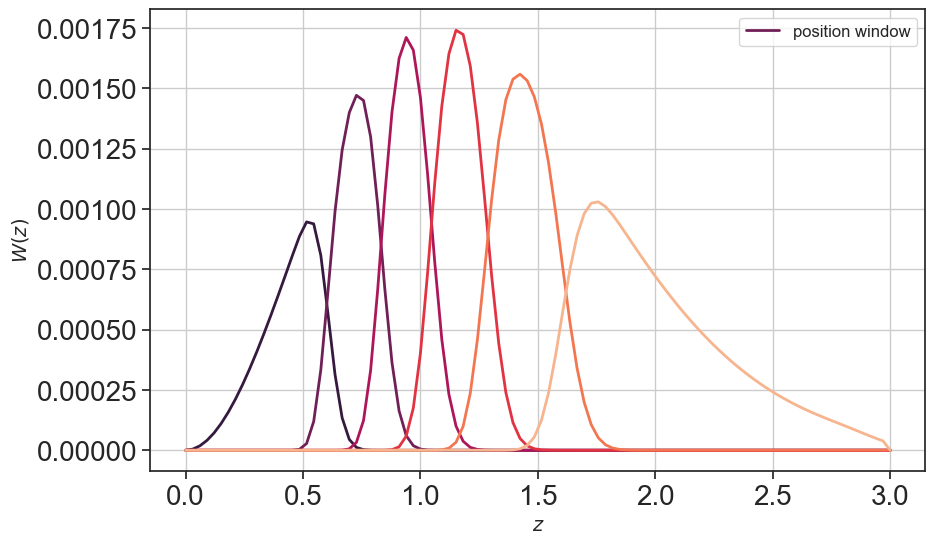

In [84]:
colors = sns.color_palette("rocket", len(nz_heracles.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop
for i in range(0, 6):
    # Plot the window
    plt.plot(nonlinear_perturbations.z, 
             tracer_pos.get_window(nonlinear_perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i], 
             label=f'position window' if i == 1 else "")
    

# Label the axes
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$W(z)$', fontsize=14)

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

## Angular power spectra

### Theoretical Predictions

In [85]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells_GG = twopoint_pospos.get_Cl(ells, nl, linear_perturbations.k)
cells_GGL = twopoint_shepos.get_Cl(ells, nl, linear_perturbations.k)
cells_EE = twopoint_sheshe.get_Cl(ells, nl, linear_perturbations.k)

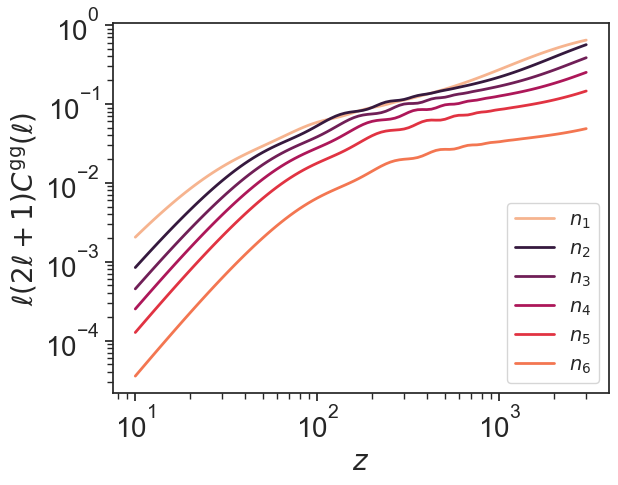

In [98]:
%timeit
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_GG[:, i, i], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_heracles.keys()))[i-1])
plt.xlabel(r'$z$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);

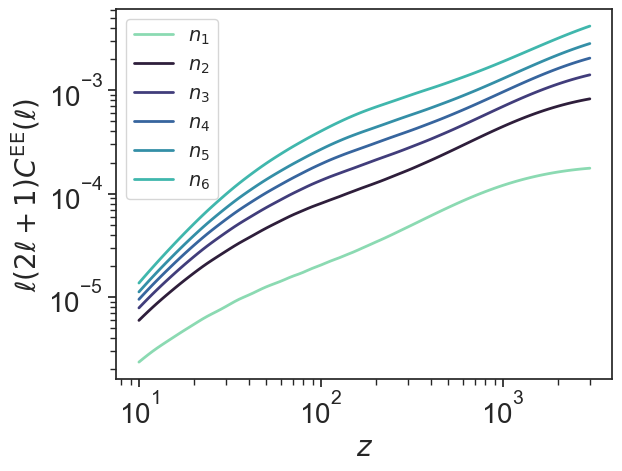

In [97]:
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_EE[:, i, i], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("mako", len(nz_heracles.keys()))[i-1])
plt.xlabel(r'$z$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm EE}(\ell)$');
plt.legend(fontsize=14);

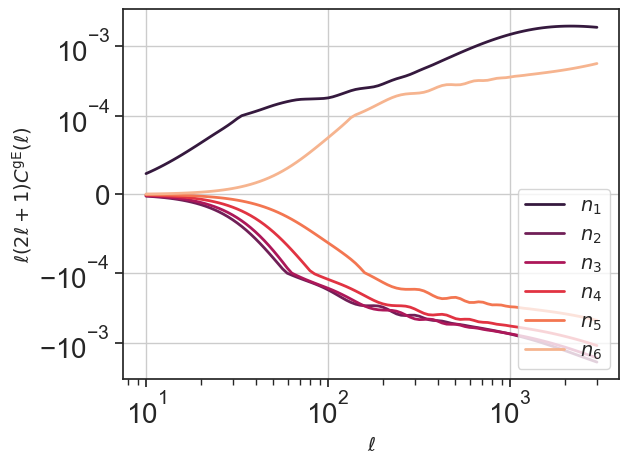

In [106]:
for i in range(0, 6):
    plt.plot(ells, 
             ells * (2 * ells + 1) * cells_GGL[:, i, i], 
             label=f'$n_{{{i+1}}}$', 
             linewidth=2, 
             color=sns.color_palette("rocket", len(nz_heracles.keys()))[i])

# Labels and legend
plt.xlabel(r'$\ell$', fontsize=14)
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gE}(\ell)$', fontsize=14)
plt.legend(fontsize=14, loc=4)

# Set y-axis to symmetric log scale to handle negative values
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('log')
# Show the grid and the plot
plt.grid(True)
plt.show()

### Data vectors

In [264]:
import fitsio, re
from numpy.typing import NDArray, DTypeLike
from typing import Any

In [270]:
def normalize_result_axis(axis, result, ell):
    """Return an axis tuple for a result."""
    try:
        from numpy.lib.array_utils import normalize_axis_tuple
    except ModuleNotFoundError:
        from numpy.lib.stride_tricks import normalize_axis_tuple

    if axis is None:
        if result.ndim == 0:
            axis = ()
        elif isinstance(ell, tuple):
            axis = tuple(range(-len(ell), 0))
        else:
            axis = -1
    return normalize_axis_tuple(axis, result.ndim, "axis")

#@dataclass(frozen=True, repr=False)
class Result:
    """
    Container for results.
    """

    array: NDArray[Any]
    ell: NDArray[Any] 
    axis: int 
    lower: NDArray[Any] 
    upper: NDArray[Any]  
    weight: NDArray[Any] 

    def __post_init__(self) -> None:
        axis = normalize_result_axis(self.axis, self.array, self.ell)
        object.__setattr__(self, "axis", axis)

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(axis={self.axis!r})"

    def __array__(self, dtype=None, *, copy=None) -> NDArray[Any]:
        if copy is not None:
            # copy being set means NumPy v2, so it's safe to pass it on
            return self.array.__array__(dtype, copy=copy)
        # NumPy v1 might not know about copy
        return self.array.__array__(dtype)

    def __getitem__(self, key):
        return self.array[key]

    @property
    def ndim(self) -> int:
        return self.array.ndim

    @property
    def shape(self) -> tuple[int, ...]:
        return self.array.shape

    @property
    def dtype(self) -> DTypeLike:
        return self.array.dtype


def _key_from_string(s: str):
    """
    Return key for a given string representation.
    """
    parts = re.split(r"(?<!\\)-", s.replace("\\\\", "\0"))
    if len(parts) > 1:
        return tuple(map(_key_from_string, parts))
    key = parts[0]
    key = key.replace("\\-", "-")
    key = key.replace("\0", "\\")
    return int(key) if key.removeprefix("-").isdigit() else key

def _read_result(hdu):
    """
    Read a result array from FITS.
    """

    from ast import literal_eval

    # read columnar data from extension
    data = hdu.read()
    h = hdu.read_header()

    print(h["ELLAXIS"])
    # the angular axis
    try:
        axis = literal_eval(h["ELLAXIS"])
    except ValueError:
        # Fallback in case it's a simple integer
        axis = [int(h["ELLAXIS"])]  # Convert it to a list or tuple if it's a single integer

    # get data array and move axis back to right position
    arr = np.moveaxis(data["ARRAY"], tuple(range(len(axis))), axis)

    # sort ell axes into natural order
    order = np.argsort(axis)

    # get ells
    _ell = data["ELL"]
    if _ell.ndim == 1:
        ell = _ell
    else:
        ell = tuple(_ell[: arr.shape[axis[i]], i] for i in order)

    # get lower bounds
    _lower = data["LOWER"]
    if _lower.ndim == 1:
        lower = _lower
    else:
        lower = tuple(_lower[: arr.shape[axis[i]], i] for i in order)

    # get upper bounds
    _upper = data["UPPER"]
    if _upper.ndim == 1:
        upper = _upper
    else:
        upper = tuple(_upper[: arr.shape[axis[i]], i] for i in order)

    # get weights
    _weight = data["WEIGHT"]
    if _weight.ndim == 1:
        weight = _weight
    else:
        weight = tuple(_weight[: arr.shape[axis[i]], i] for i in order)

    # construct result array with ancillary arrays and metadata
    return Result(
        arr.view(np.dtype(arr.dtype, metadata=_read_metadata(hdu))),
        axis=tuple(axis[i] for i in order),
        ell=ell,
        lower=lower,
        upper=upper,
        weight=weight,
    )

def _read_metadata(hdu):
    """read array metadata from FITS HDU"""
    h = hdu.read_header()
    md = {}
    for key in h:
        if key.startswith("META "):
            md[key[5:].lower()] = h[key]
    return md


def read(path):
    """
    Read a set of results from a FITS file.
    """

    # the returned set of cls
    results = {}

    # read all HDUs in file into dict keys
    with fitsio.FITS(path) as fits:
        for hdu in fits:
            if not hdu.has_data():
                continue
            ext = hdu.get_extname()
            if not ext:
                continue
            key = _key_from_string(ext)
            if not key:
                continue
            results[key] = _read_result(hdu)

    return results


In [271]:
cls = read('/Users/guadalupe.canasherr/cloelite-dev/protocols-up-to-date/cloelite/notebooks/data/example-spectra.fits')

1


ValueError: malformed node or string: 1

In [211]:
cells.keys()

dict_keys([('POS', 'POS', 1, 1), ('POS', 'SHE', 1, 1), ('POS', 'POS', 1, 2), ('POS', 'SHE', 1, 2), ('POS', 'POS', 1, 3), ('POS', 'SHE', 1, 3), ('POS', 'POS', 1, 4), ('POS', 'SHE', 1, 4), ('POS', 'POS', 1, 5), ('POS', 'SHE', 1, 5), ('POS', 'POS', 1, 6), ('POS', 'SHE', 1, 6), ('SHE', 'SHE', 1, 1), ('POS', 'SHE', 2, 1), ('SHE', 'SHE', 1, 2), ('POS', 'SHE', 3, 1), ('SHE', 'SHE', 1, 3), ('POS', 'SHE', 4, 1), ('SHE', 'SHE', 1, 4), ('POS', 'SHE', 5, 1), ('SHE', 'SHE', 1, 5), ('POS', 'SHE', 6, 1), ('SHE', 'SHE', 1, 6), ('POS', 'POS', 2, 2), ('POS', 'SHE', 2, 2), ('POS', 'POS', 2, 3), ('POS', 'SHE', 2, 3), ('POS', 'POS', 2, 4), ('POS', 'SHE', 2, 4), ('POS', 'POS', 2, 5), ('POS', 'SHE', 2, 5), ('POS', 'POS', 2, 6), ('POS', 'SHE', 2, 6), ('SHE', 'SHE', 2, 2), ('POS', 'SHE', 3, 2), ('SHE', 'SHE', 2, 3), ('POS', 'SHE', 4, 2), ('SHE', 'SHE', 2, 4), ('POS', 'SHE', 5, 2), ('SHE', 'SHE', 2, 5), ('POS', 'SHE', 6, 2), ('SHE', 'SHE', 2, 6), ('POS', 'POS', 3, 3), ('POS', 'SHE', 3, 3), ('POS', 'POS', 3, 4),

In [213]:
cells['POS', 'POS', 1, 1].dtype

dtype([('ARRAY', '>f8'), ('ELL', '>f8'), ('LOWER', '>f8'), ('UPPER', '>f8'), ('WEIGHT', '>f8')])

In [159]:
with fitsio.FITS('../data/example-spectra.fits') as fits:
    print([hdu.get_extname() for hdu in fits])

['', 'POS-POS-1-1', 'POS-SHE-1-1', 'POS-POS-1-2', 'POS-SHE-1-2', 'POS-POS-1-3', 'POS-SHE-1-3', 'POS-POS-1-4', 'POS-SHE-1-4', 'POS-POS-1-5', 'POS-SHE-1-5', 'POS-POS-1-6', 'POS-SHE-1-6', 'SHE-SHE-1-1', 'POS-SHE-2-1', 'SHE-SHE-1-2', 'POS-SHE-3-1', 'SHE-SHE-1-3', 'POS-SHE-4-1', 'SHE-SHE-1-4', 'POS-SHE-5-1', 'SHE-SHE-1-5', 'POS-SHE-6-1', 'SHE-SHE-1-6', 'POS-POS-2-2', 'POS-SHE-2-2', 'POS-POS-2-3', 'POS-SHE-2-3', 'POS-POS-2-4', 'POS-SHE-2-4', 'POS-POS-2-5', 'POS-SHE-2-5', 'POS-POS-2-6', 'POS-SHE-2-6', 'SHE-SHE-2-2', 'POS-SHE-3-2', 'SHE-SHE-2-3', 'POS-SHE-4-2', 'SHE-SHE-2-4', 'POS-SHE-5-2', 'SHE-SHE-2-5', 'POS-SHE-6-2', 'SHE-SHE-2-6', 'POS-POS-3-3', 'POS-SHE-3-3', 'POS-POS-3-4', 'POS-SHE-3-4', 'POS-POS-3-5', 'POS-SHE-3-5', 'POS-POS-3-6', 'POS-SHE-3-6', 'SHE-SHE-3-3', 'POS-SHE-4-3', 'SHE-SHE-3-4', 'POS-SHE-5-3', 'SHE-SHE-3-5', 'POS-SHE-6-3', 'SHE-SHE-3-6', 'POS-POS-4-4', 'POS-SHE-4-4', 'POS-POS-4-5', 'POS-SHE-4-5', 'POS-POS-4-6', 'POS-SHE-4-6', 'SHE-SHE-4-4', 'POS-SHE-5-4', 'SHE-SHE-4-5', 'POS-

In [157]:
_iterfits('../data/example-spectra.fits', "POS-POS")

<generator object _iterfits at 0x3ed91c0b0>